# Faglitteratur
Korpus - fra BBI-prosjekt

Lars G. Bagøien Johnsen

Kristin Ørjasæter

In [2]:
import dhlab as dh
import pandas as pd

# Henter korpuset 

In [3]:
corpus = pd.read_csv("barn.csv", index_col=0, low_memory=False).fillna('')

In [4]:
corpus.head(5)

,dhlabid,urn,lenker,title,authors,oaiid,city,year,publisher,langs,...,ddc,genres,literaryform,kristin,sesamid,isbn10,timestamp,doctype,ocr_creator,ocr_timestamp
78,100289681,URN:NBN:no-nb_digibok_2016041448047,Vis element,Eventyret om fanden i nøtten,"Asbjørnsen , Peter Christen / Moe , Jørgen / M...",,Oslo,1945.0,Damm,nob,...,,,Skjønn,Skjønn,,,,,,
59,100213176,URN:NBN:no-nb_digibok_2014071508018,Vis element,Farlig spill : en guttefortelling,"Ask , Espen / Brandvold , Åshild",,Oslo,1945.0,Ekko,nob,...,,,Skjønn,Skjønn,,,,,,
117,100309755,URN:NBN:no-nb_digibok_2016090948102,Vis element,Finnmarks-Ravna,"Ott , Estrid / Treider , Esther Normann . / Gj...",,Oslo,1945.0,Gyldendal,nob / dan,...,,fiction,Skjønnlitteratur,,,,,,,
17,100226008,URN:NBN:no-nb_digibok_2014091708167,Vis element,Flagg over Vangen : forteljing om Vangsgutane,"Halse , Leif / Nilssen , Jens R.",,Oslo,1945.0,Fonna,nno,...,,,Skjønn,Skjønn,,,,,,
24,100572774,URN:NBN:no-nb_digibok_2007011200043,Vis element,Fra 9. april til 7. juni : episoder og oplevel...,"Gotaas , Birger",,,1945.0,Dybwad,nob,...,948.1053,,Fag,Fag,,,,,,


In [8]:
corpus = corpus[~corpus.authors.str.contains("Mørk.*Lers*")]

## Går videre med skjønnlitteratur

In [9]:
c = corpus[corpus.literaryform.str.contains("ag")]

In [10]:
c.head(5)

,dhlabid,urn,lenker,title,authors,oaiid,city,year,publisher,langs,...,ddc,genres,literaryform,kristin,sesamid,isbn10,timestamp,doctype,ocr_creator,ocr_timestamp
24,100572774,URN:NBN:no-nb_digibok_2007011200043,Vis element,Fra 9. april til 7. juni : episoder og oplevel...,"Gotaas , Birger",,,1945.0,Dybwad,nob,...,948.1053,,Fag,Fag,,,,,,
77,100274647,URN:NBN:no-nb_digibok_2016010408131,Vis element,Avisgutten : som ble verdens største oppfinner,"Amundsen , Sverre S.",,Oslo,1945.0,Aschehoug,nob,...,,,Fag,Fag,,,,,,
23,100572672,URN:NBN:no-nb_digibok_2007011100107,Vis element,Hurra for han som innstifta da'n!,"Holt , Kåre / Brochmann , Odd",,Oslo,1945.0,Gyldendal,nob,...,,,Fag,Fag,,,,,,
113,100028909,URN:NBN:no-nb_digibok_2008041604103,Vis element,Prøv igjen : boken til ungdommen som vil fram,"Møller-Jensen , Jens / Harbitz , Alf / Imsland...",,Stavanger,1945.0,Stabenfeldt,nob / dan,...,,,Fag,Fag,,,,,,
83,100311123,URN:NBN:no-nb_digibok_2016091248080,Vis element,Rare dyr fra fremmede land,"Mjøen , Heljar / Brochmann , Odd",,Oslo,1945.0,Aschehoug,nob,...,,,Fag,Fag,,,,,,


# Ordgrupper og kategorier

In [11]:
word_groups = {
  "funksjonsnedsettelse": [
    "handikappet", "funksjonshemmet", "blind", "svaksynt",
    "døv", "tunghørt", "hørselshemmet",
    "klumpfot", "albino",
    "rullestolbruker", "bevegelseshemmet",
    "psykisk utviklingshemmet", "autistisk", "autisme",
    "dyslektiker", "epileptiker"
  ],

  "utseende_kropp": [
    "tykk", "tynn", "høy", "lav", "kraftig", "overvektig",
    "undervektig"
  ],

  "seksuell_legning_kjønn": [
    "trans", "transe", "transkjønnet",
    "homofil", "homse",
    "lesbisk", "lesbe",
    "bi", "bifil",
    "panfil", "aseksuell", "queer"
  ],

  "egennavn": [
    "fornavn", "etternavn", "personnavn", "stedsnavn"
  ],

  "nasjonalitet": [
    "pakistansk", "arabisk", "afrikansk", "grønlender", "grønlandsk",
    "islandsk", "polsk", "russer", "russisk", "amerikaner",
    "hindu", "japaner", "asiat", "kineser", "tysker", "franskmann",
    "britisk", "engelsk", "svensk", "dansk", "finsk",
    "norsk", "samisk", "litauer", "ukrainer", "spanjol", "italiener",
    "portugiser"
  ],

  "geografi": [
    "norden", "europa", "asia", "amerika", "afrika",
    "australia", "antarktis", "arktis", "ural",
    "balkan", "kaukasus", "midtøsten", "skandinavia"
  ],

  "språk": [
    "engelsk", "pakistansk", "urdu",
    "svensk", "dansk", "finsk", "islandsk", "grønlandsk", "samisk",
    "fransk", "tysk", "polsk", "litauisk", "russisk",
    "italiensk", "spansk", "castillano", "portugisisk",
    "kinesisk", "japansk", "tamil", "arabisk", "swahili",
    "norsk", "nynorsk", "bokmål", "latin",
    "gresk", "hebraisk", "persisk", "kurdisk"
  ],

  "religion": [
    "kristendom", "hinduisme", "islam", "muhammedanisme",
    "taoisme", "jødedom", "koptisk", "katolisisme",
    "protestantisme", "ortodoksi", "buddhisme", "sikhisme"
  ],

  "kultur_markorer": [
    "urfolk", "indianer", "araber", "afrikaner",
    "amerikaner", "europeer", "nordisk", "samisk",
    "romfolk", "sinti", "keltisk",
    "innvandrer", "minoritet"
  ]
}

In [8]:
words = [x for y in word_groups for x in word_groups[y]]

In [9]:
mapping = {x:y for y in word_groups for x in word_groups[y]}
    

# Henter ut URNer fra korpuset og tar bort mulige feil

In [10]:
urns = [x for x in c.urn.to_list() if isinstance(x, str)]

# Teller alle ordene

In [11]:
counts = dh.Counts(corpus = urns, words = words)

In [12]:
counts = counts.frame

In [30]:
counts.to_pickle("faglitteratur.pkl")

# Legger gruppene til datarammen

In [14]:
counts["group"] = counts.index.map(lambda w: mapping.get(w, None))

In [15]:
counts.head(5)

urn,100001722,100002021,100002182,100002218,100002222,100002293,100002300,100002336,100002365,100002421,...,100711594,100712052,100712240,100712370,100712492,100713057,100713752,100713807,100714451,group
word,,,,,,,,,,,,,,,,,,,,,
afrika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi
afrikaner,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kultur_markorer
afrikansk,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,nasjonalitet
albino,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,funksjonsnedsettelse
amerika,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,geografi


# Utfører telling og normalisering

In [16]:
# anta:
# counts: index = ord
#         kolonner = dhlabid ... + 'group'
# years_df: kolonner ['dhlabid', 'year']

# 0: lag en ren years-Series med unik index
years = (
    c
    .drop_duplicates("dhlabid")
    .set_index("dhlabid")["year"]
).dropna().astype(int)

counts.columns = counts.columns.astype(str)
c["dhlabid"] = c["dhlabid"].astype(str)

# 1: dokumentkolonnene i counts (alle unntatt 'group')
doc_cols = counts.columns.drop("group")

# 2: felles dhlabid mellom counts og years
common = doc_cols.intersection(years.index)

# 3: trekk ut bare de dokumentene vi har både counts og år for
X = counts[common]              # ord × dokument
years_valid = years.loc[common] # index = dhlabid, value = år

/tmp/ipykernel_755526/1963893982.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c["dhlabid"] = c["dhlabid"].astype(str)


In [17]:
# 4: ord × år (summerer alle docs med samme år)
word_by_year = X.groupby(years_valid, axis=1).sum()

# 5: grupper × år
group_by_year = (
    word_by_year
    .assign(group=counts["group"])
    .groupby("group")
    .sum()                      # her forsvinner 'group'-kolonnen, år-kolonner blir igjen
    .sort_index(axis=1)         # sortér år langs kolonne-aksen
)

/tmp/ipykernel_755526/234373164.py:2: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  word_by_year = X.groupby(years_valid, axis=1).sum()


In [18]:
group_by_year

year,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
group,,,,,,,,,,,,,,,,,,,,,
egennavn,7.0,2.0,6.0,2.0,9.0,2.0,1.0,0.0,4.0,2.0,...,25.0,33.0,30.0,20.0,22.0,2.0,12.0,11.0,7.0,0.0
funksjonsnedsettelse,17.0,6.0,10.0,9.0,22.0,37.0,9.0,13.0,11.0,17.0,...,57.0,116.0,97.0,70.0,70.0,11.0,37.0,5.0,5.0,3.0
geografi,3.0,0.0,0.0,12.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,4.0,4.0,3.0,1.0,0.0,3.0,2.0,0.0,0.0
kultur_markorer,51.0,1.0,23.0,11.0,44.0,32.0,23.0,30.0,16.0,3.0,...,77.0,148.0,137.0,161.0,34.0,8.0,161.0,57.0,19.0,4.0
nasjonalitet,19.0,16.0,27.0,12.0,33.0,14.0,22.0,74.0,16.0,2.0,...,73.0,127.0,137.0,53.0,33.0,16.0,16.0,10.0,9.0,3.0
religion,4.0,7.0,17.0,1.0,23.0,2.0,13.0,7.0,0.0,1.0,...,62.0,25.0,126.0,78.0,101.0,2.0,11.0,68.0,9.0,3.0
seksuell_legning_kjønn,2.0,5.0,10.0,5.0,13.0,22.0,3.0,51.0,12.0,2.0,...,42.0,79.0,339.0,63.0,101.0,21.0,57.0,8.0,6.0,4.0
språk,512.0,152.0,370.0,275.0,884.0,549.0,413.0,337.0,249.0,115.0,...,1758.0,1430.0,1827.0,1374.0,946.0,273.0,638.0,402.0,301.0,38.0
utseende_kropp,178.0,102.0,366.0,217.0,356.0,372.0,254.0,231.0,243.0,289.0,...,856.0,850.0,939.0,747.0,590.0,202.0,270.0,115.0,70.0,18.0


# Visualisering

In [19]:
import matplotlib.pyplot as plt

def smooth_plot(df, window=5, lw=4, alpha=0.7, figsize=(16,8)):
    sm = df.rolling(window=window, min_periods=1).mean()
    ax = sm.plot(lw=lw, alpha=alpha, figsize=figsize)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    return ax

In [20]:
# grupper × år  →  år × grupper
T = group_by_year.T

# glatt over år (langs index, ingen axis-argument)
smooth_T = T.rolling(window=5, center=True).mean()

# tilbake til grupper × år
smooth = smooth_T

# Plot over forekomster pr. år

<Axes: xlabel='year'>

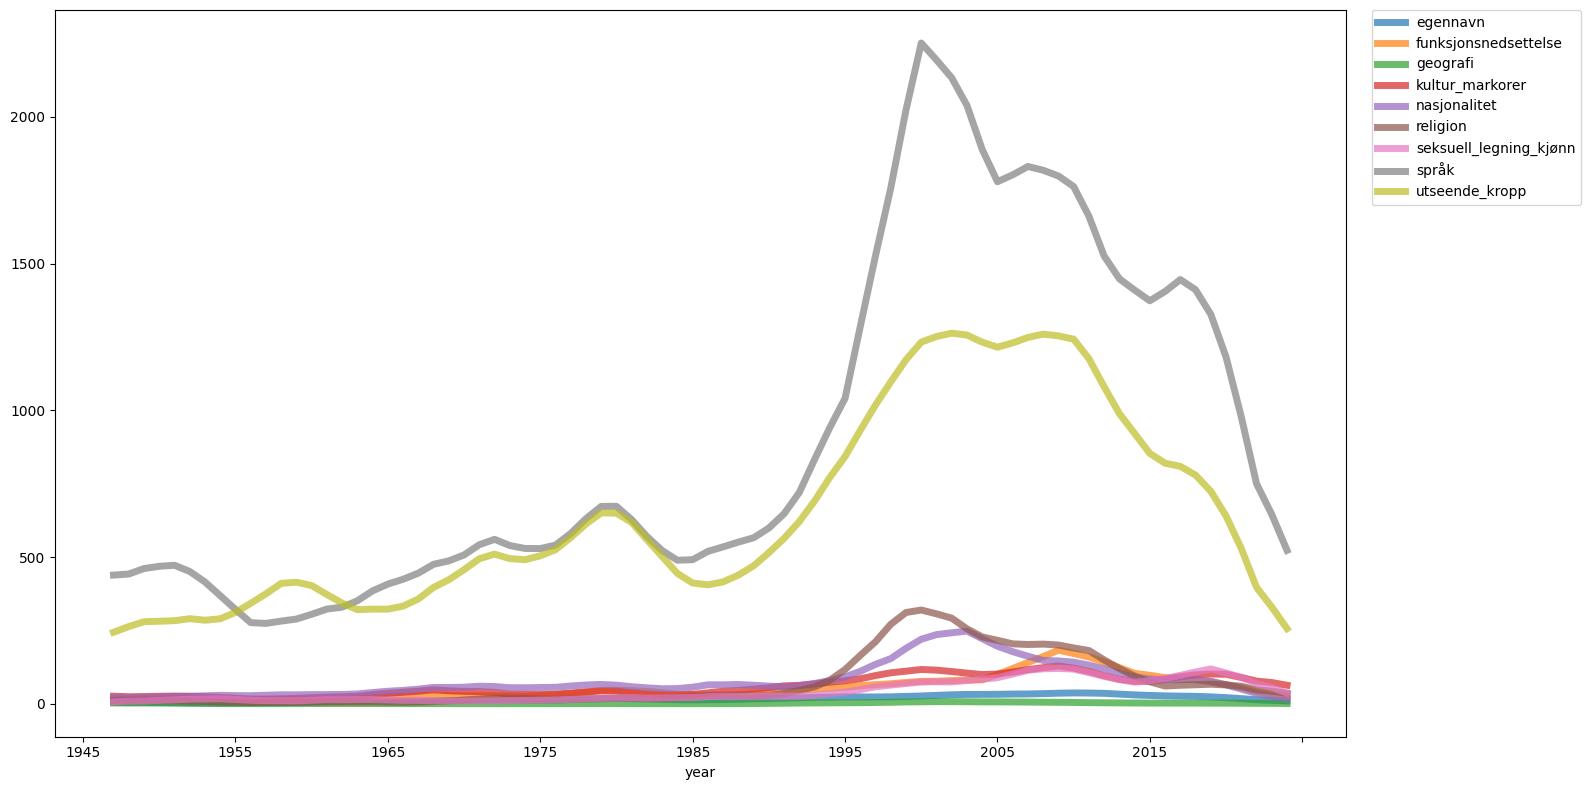

In [21]:
smooth_plot(smooth,lw=5,figsize=(16,8))

# Sjekk normalisering innen hver gruppe, hvor er det tettes

In [22]:
# grupper × år
group_norm_cohort = group_by_year.div(group_by_year.sum(axis=1), axis=0)

<Axes: xlabel='year'>

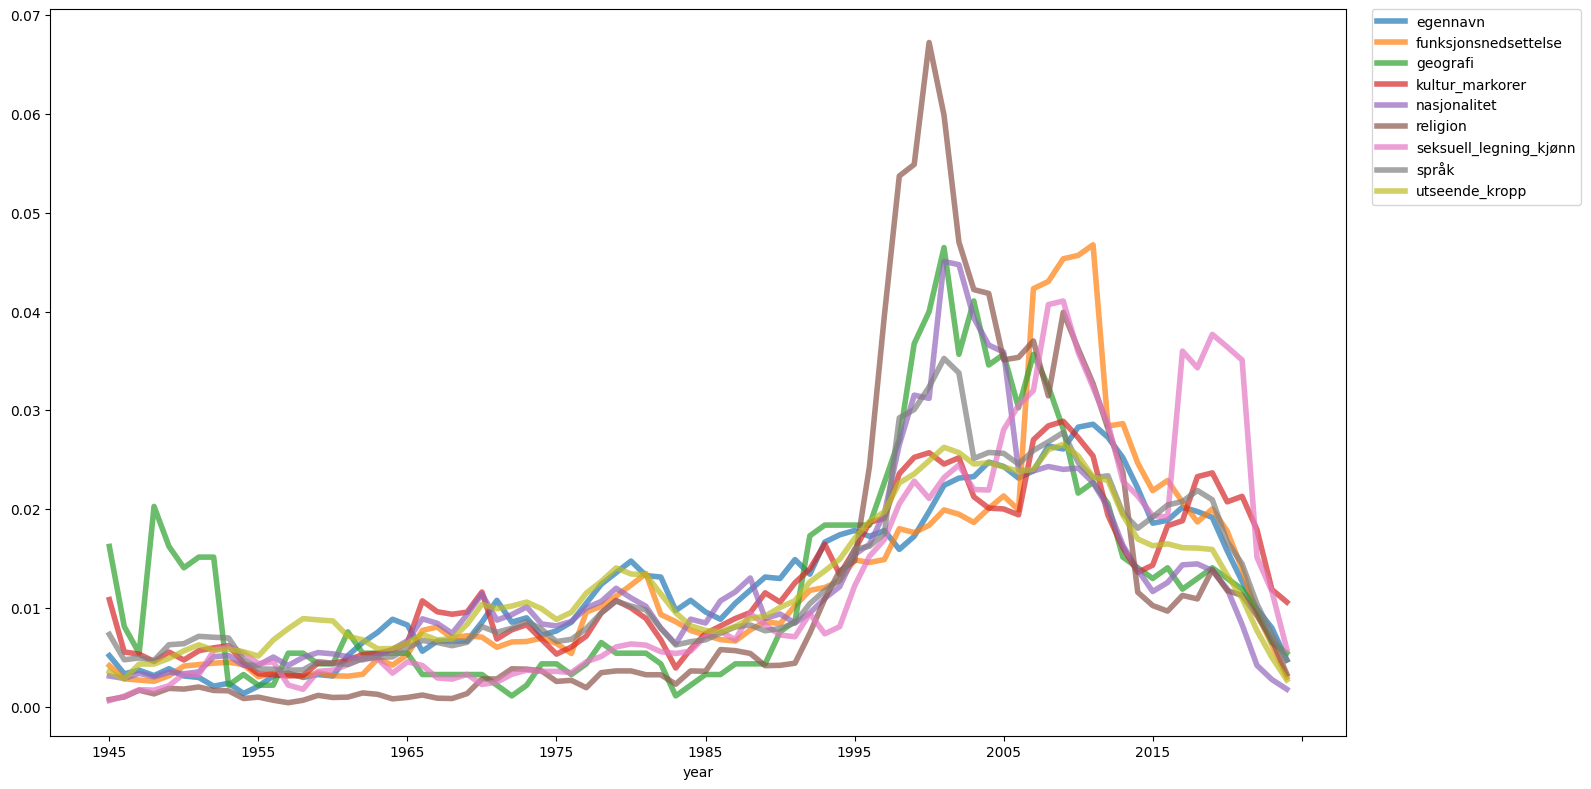

In [23]:
smooth_plot(group_norm_cohort.T)

# Sjekk gruppene mot hverandre pr.år

In [24]:
group_norm_year = group_by_year.div(group_by_year.sum(axis=0), axis=1)

<Axes: xlabel='year'>

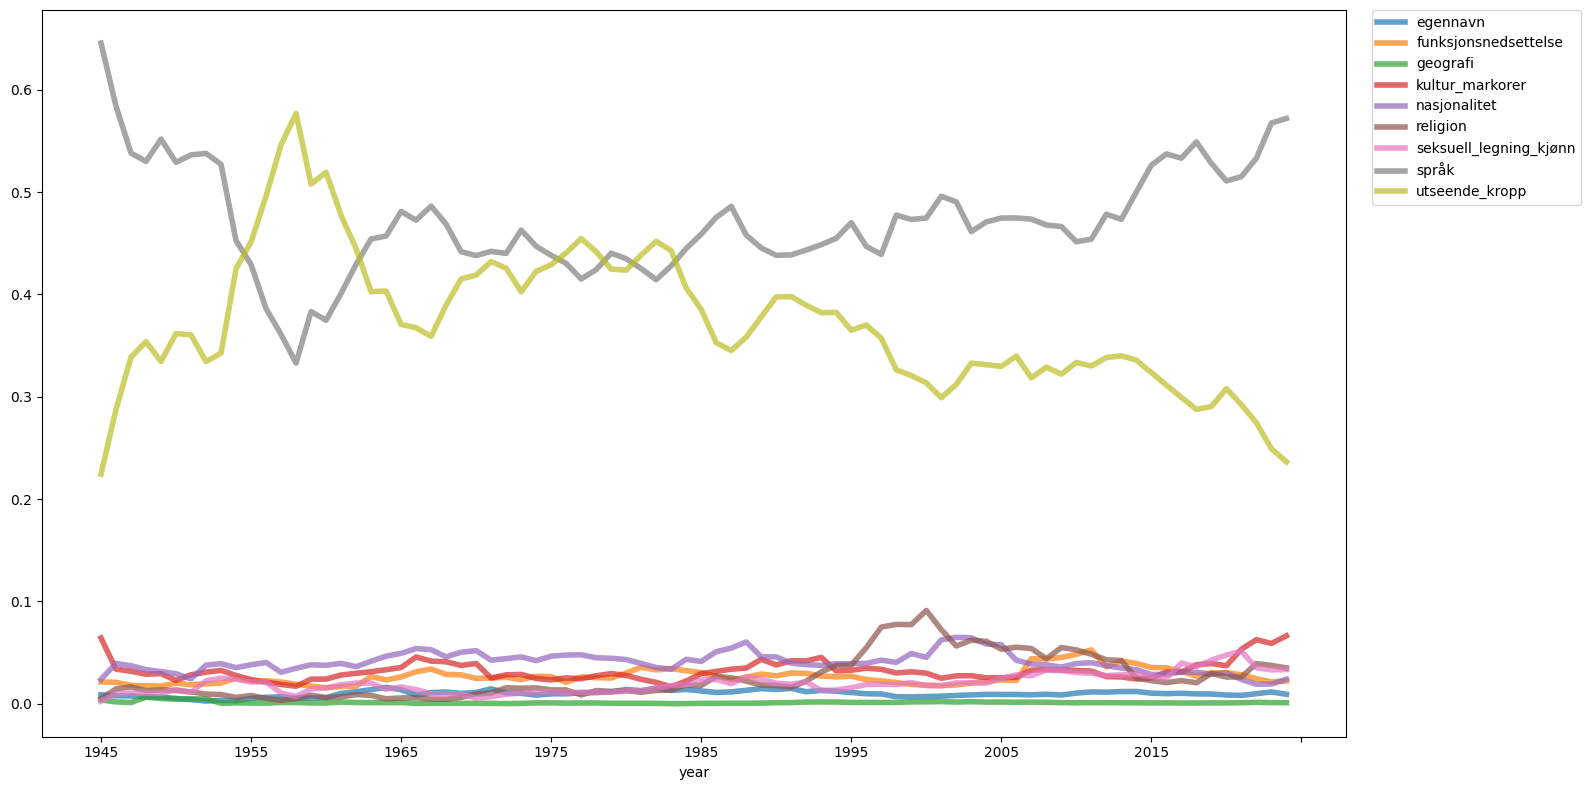

In [27]:
smooth_plot(group_norm_year.T)

<Axes: xlabel='year'>

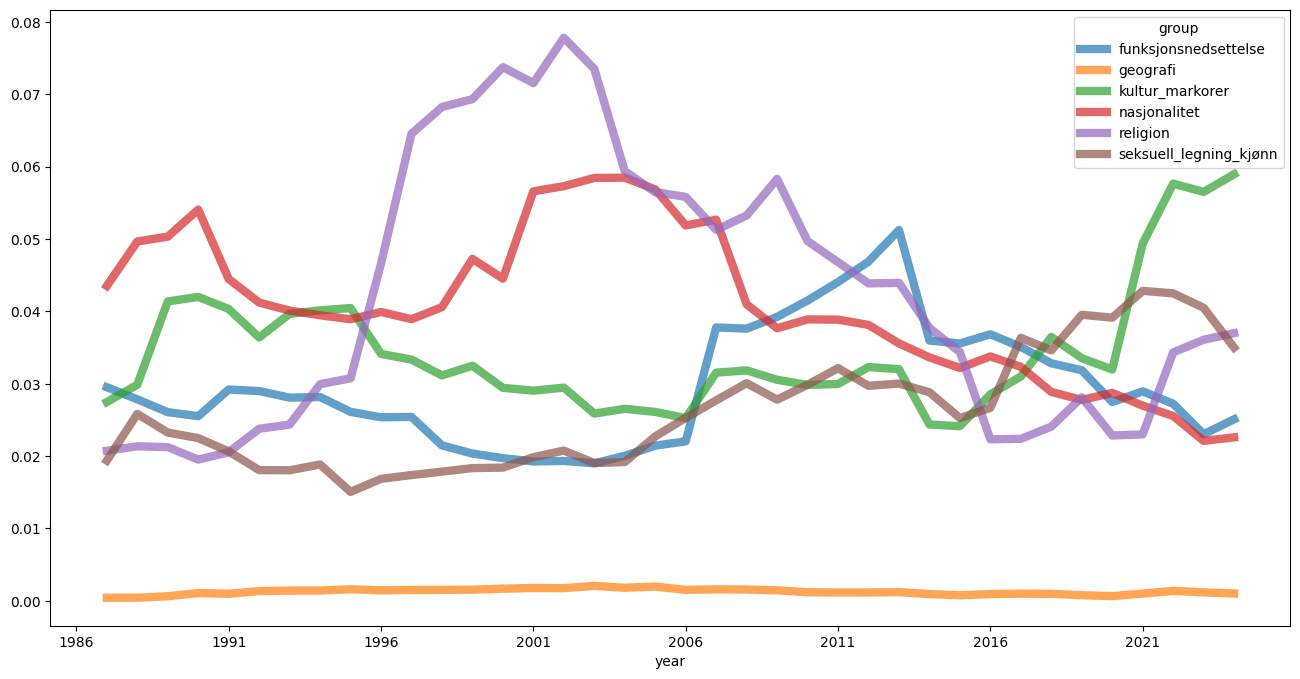

In [28]:
df = group_norm_year.loc[['funksjonsnedsettelse', 'geografi', 'kultur_markorer',
       'nasjonalitet', 'religion', 'seksuell_legning_kjønn']].T
df[df.index > 1980].rolling(window=7).mean().plot(lw=6, alpha=0.7,figsize=(16,8))

In [29]:

# antall forekomster per ord og gruppe (du har counts + group)
word_totals = counts.drop(columns=["group"]).sum(axis=1)       # total frekvens per ord
word_totals = word_totals.to_frame("freq").assign(group=counts["group"])

# velg én gruppe
g = "kultur_markorer"
cands = word_totals.query("group == @g").sort_values("freq", ascending=False)

# ta f.eks. topp 10 ord i denne gruppen
top_words = cands.head(10).index.tolist()
top_words

['samisk',
 'nordisk',
 'amerikaner',
 'indianer',
 'europeer',
 'araber',
 'keltisk',
 'minoritet',
 'urfolk',
 'innvandrer']